In [1]:
import numpy as np
import matplotlib.pyplot as plt

### lineer Model Regression
###  𝑓𝑤,𝑏(𝑥(𝑖))=𝑤𝑥(𝑖)+𝑏

### Training set

In [2]:
x_train = np.array([1.0,1.2,1.8,2.4])
y_train = np.array([240.0,320.0,365.0,400.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1.  1.2 1.8 2.4]
y_train = [240. 320. 365. 400.]


### Number of training examples : m


In [3]:
# m is number of training examples
print(f"x_train shape is {x_train.shape}")
m = x_train.shape[0]
print(f"number of examples are {m}")

x_train shape is (4,)
number of examples are 4


### Training example : (x_i, y_i)


In [4]:
i=1
x_i = x_train[i]
y_i = y_train[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

(x^(1), y^(1)) = (1.2, 320.0)


### Plotting the Data

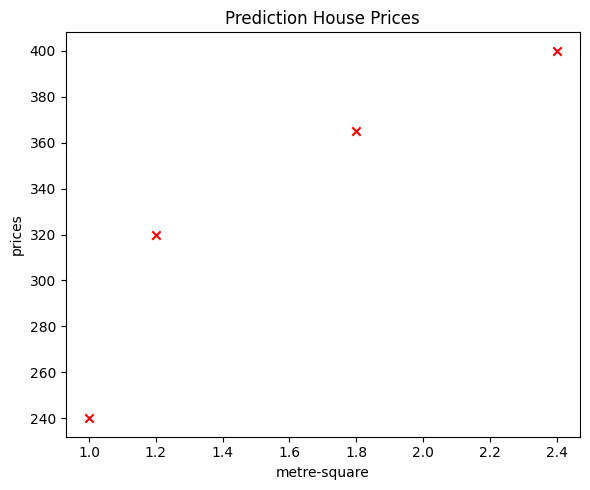

In [5]:
fig ,ax = plt.subplots(figsize=(6,5))
ax.scatter(x_train,y_train,marker="x",c="r")
ax.set_title("Prediction House Prices")
ax.set_xlabel("metre-square")
ax.set_ylabel("prices")
plt.tight_layout()
plt.show()

### Model Function
### $$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

In [6]:
w = 175
b = 65
print(f"w = {w} , b = {b}")

w = 175 , b = 65


In [7]:
def compute_model_output(x,w,b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b 
    return f_wb
        

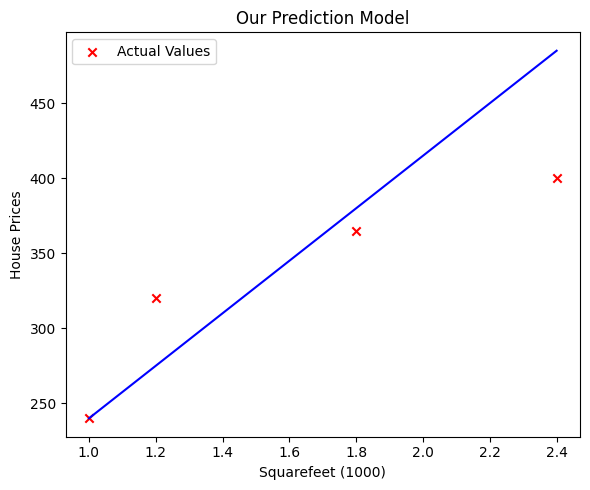

In [8]:
fig , ax = plt.subplots(figsize=(6,5))
temp_f_wb = compute_model_output(x_train,w,b)
#plotting our model prediction
ax.plot(x_train,temp_f_wb,c="b")
#plotting the data points
ax.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')
ax.set_xlabel("Squarefeet (1000)")
ax.set_ylabel("House Prices")
ax.set_title("Our Prediction Model")
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
x_3 = 1.4
cost_1200sqft = w * x_3 + b
print(f"prediction of x_3 = {cost_1200sqft}")

prediction of x_3 = 310.0


## Cost Function
<img src="images/maliyet.png" width="600">

## The equation for cost with one variable is:
$$\huge J(w,b) = \frac{1}{2m} \sum_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$

In [10]:
def compute_cost(x_train,y_train,w,b):
    m = x_train.shape[0]
    total_cost = 0
    for i in range(m):
        f_wb_i = w * x_train[i] + b # calculate the estimated values. f_wb isnt necessary to return so no need to define as a list
        total_cost += (y_train[i]-f_wb_i)**2
    return (total_cost/(2*m))

In [11]:
compute_cost(x_train, y_train, 200, 100)

np.float64(5678.125)

<a name="toc_40291_2.1"></a>
## Gradient descent summary
So far in this course, you have developed a linear model that predicts $f_{w,b}(x^{(i)})$:
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2\tag{2}$$ 


In lecture, *gradient descent* was described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

Start coding with :
$$
\huge\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$



<img src="images/slope.png" width="300">


In [12]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb_i = w * x[i] + b
        err = f_wb_i - y[i]
        dj_dw += err * x[i]
        dj_db += err

    return dj_dw / m , dj_db / m
        


<img src="images/resim3.png" width="400">




$$\huge \begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$

In [13]:
def gradient_descent(x,y,w_init,b_init,alpha,num_iters):
    w = w_init
    b = b_init
    for i in range(num_iters):
        dj_dw , dj_db = compute_gradient(x,y,w,b)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

    if i % 1000 == 0:
            maliyet = compute_cost(x, y, w, b)
            print(f"Adım {i:5} | Maliyet (Hata): {maliyet:9.2f} | w: {w:7.2f} | b: {b:7.2f}")

    return w,b

In [14]:
w_init = 0
b_init = 0
alpha = 0.01
num_iters = 10000
w_final,b_final = gradient_descent(x_train,y_train,w_init,b_init,alpha,num_iters)
print(f"w = {w_final:.2f}")
print(f"b = {b_final:.2f}")


w = 100.85
b = 169.89


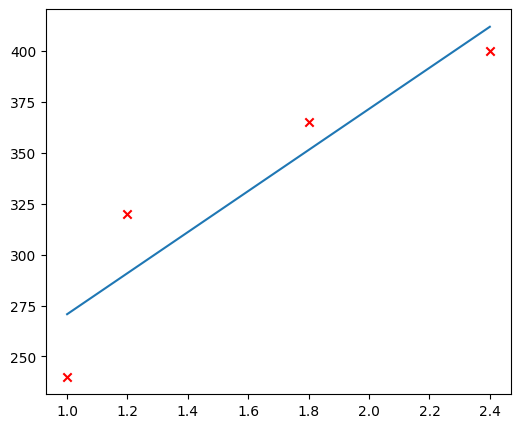

In [15]:
fig , ax = plt.subplots(figsize = (6,5))
guesses = compute_model_output(x_train,w_final,b_final)
ax.scatter(x_train,y_train,marker="x",c="r")
ax.plot(x_train,guesses)
